<a href="https://colab.research.google.com/github/WoojinCho-Ryan/Studying-Pytorch/blob/main/Transformer_Model_Tutorial_in_PyTorch_From_Theory_to_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[TUTORIAL](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch)

# Building the Transformer Model with PyTorch

## 1. Importing the necessary libraries and modules

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy

## 2. Defining the basic building blocks: Multi-Head Attention, Position-wise Feed-Forward Networks, Positional Encoding

### Multi-head attention

The multi-head attention mechanism computes the attention between each pair of positions in a sequence. It consists of multiple “attention heads” that capture different aspects of the input sequence.

MHA의 작동 원리는 "분할, 병렬 처리, 결합"의 3단계로 요약할 수 있음.

모델이 입력 시퀀스(sequence)의 여러 부분에 동시에 집중하되, 서로 다른 관점에서 정보를 바라볼 수 있도록 하는 메커니즘.

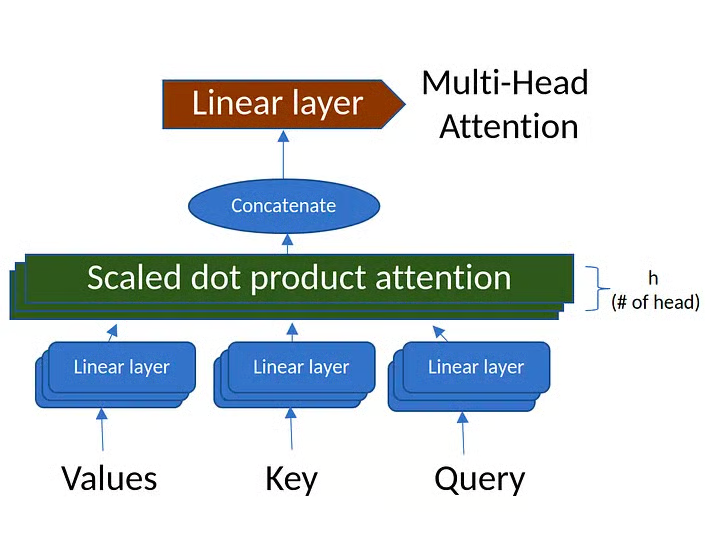


$$Attention(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$$

In [3]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    # Ensure: model dimension (d_model) is divisible by the number of heads
    # 단순하게 계산을 편하게 하기 위함이 크다.
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

    # Initialize dimensions
    self.d_model = d_model # Model's dimension
    self.num_heads = num_heads # Num. of attention heads
    self.d_k = d_model // num_heads # Dimension of each head's key, query, and value

    # Linear layers for transforming inputs
    self.W_q = nn.Linear(d_model, d_model) # Query transformation, 검색하려는 단어 또는 질문
    self.W_k = nn.Linear(d_model, d_model) # Key transformation, 사전에 등록된 표제 또는 키워드
    self.W_v = nn.Linear(d_model, d_model) # Value transformation, 각 key에 해당되는 실제 내
    self.W_o = nn.Linear(d_model, d_model) # Output transformation

  def scaled_dot_product_attention(self, Q, K, V, mask = None):
    # Calculate attention scores
    attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

    # Apply mask if provided (useful for preventing attention to certain parts like padding)
    if mask is not None:
      attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

    # Softmax is applied to obtain attention probabilities
    attn_probs = torch.softmax(attn_scores, dim = -1)

    # Multiply by values to obtain the final output
    output = torch.matmul(attn_probs, V)
    return output

  def split_heads(self, x):
    # Reshape the input to have num_heads for multi-head attention
    batch_size, seq_length, d_model = x.size()
    return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

  def combine_heads(self, x):
    # Combine the multiple heads back to original shape
    batch_size, _, seq_length, d_k = x.size()
    return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

  def forward(self, Q, K, V, mask = None):
    # Apply linear transformations and split heads
    Q = self.split_heads(self.W_q(Q))
    K = self.split_heads(self.W_k(K))
    V = self.split_heads(self.W_v(V))

    # Perform scaled dot-product attention
    attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

    # Combine heads and apply output transformation
    output = self.W_o(self.combine_heads(attn_output))
    return output